**Nida Noor**

  **Task 7**
  
  **Machine Learning Foundations: Train/Test Split, Model Fit, and Linear Regression**

In [6]:
 #Libraries Installed

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

print("Libraries: scikit-learn, pandas, numpy, and matplotlib are installed")

Libraries: scikit-learn, pandas, numpy, and matplotlib are installed


**Part A — ML Theory: Train/Test Split**
1. Explain why a dataset is split into training and testing sets, and what problem this solves.
2. Describe the typical split ratios used in practice (e.g., 80/20, 70/30) and when each is appropriate.
3. Implement a train/test split on a sample dataset using scikit-learn's train_test_split.
4. Explain the role of the random_state parameter and why it matters for reproducibility.
5. Discuss what a validation set is and how it differs from a test set.


**1. Explain why a dataset is split into training and testing sets, and what problem this solves.**
   
A dataset is split so the model learns from the training set and is evaluated on the testing set. This measures how well the model performs on unseen data and helps prevent overfitting.

**2. Describe the typical split ratios used in practice (e.g., 80/20, 70/30) and when each is appropriate.**

80/20: Most common. It provides a good balance between training and testing.
70/30: Useful for smaller datasets that need more testing data.
90/10: Suitable for very large datasets where even 10% is enough for testing.

**4. Explain the role of the random_state parameter and why it matters for reproducibility**

Random_state controls how the data is randomly split. Using the same value (e.g., 42) ensures the same train/test split every time, making results reproducible.

**5. Discuss what a validation set is and how it differs from a test set.**

**Validation Set:** Used during training to tune the model and choose the best settings.

**Test Set:** Used only after training to evaluate the final model's performance on unseen data.


In [16]:
 #3. Implement a train/test split on a sample dataset using scikit-learn's train_test_split.

import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

# Load dataset
housing = fetch_california_housing()

X=pd.DataFrame(housing.data)
y = housing.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split( X,y,test_size=0.20,random_state=42)


print(f"Total Dataset Size : {len(X)} samples")

#split ratio 
train_percent = (len(X_train) / len(X)) * 100
test_percent = (len(X_test) / len(X)) * 100

print(f"Training Set       : {len(X_train)} samples ({train_percent:.0f}%)")
print(f"Testing Set        : {len(X_test)} samples ({test_percent:.0f}%)")


print(f"Training Features  : {X_train.shape}")
print(f"Testing Features   : {X_test.shape}\n")

print(f"Training Labels    : {y_train.shape}")
print(f"Testing Labels     : {y_test.shape}")





Total Dataset Size : 20640 samples
Training Set       : 16512 samples (80%)
Testing Set        : 4128 samples (20%)
Training Features  : (16512, 8)
Testing Features   : (4128, 8)

Training Labels    : (16512,)
Testing Labels     : (4128,)


**Explanation of Part A (3)**

The dataset contains **20,640 samples**. After applying an **80/20 train-test split**, the data was divided into:

**Training Features:** 16,512 samples with 8 features each.
**Testing Features:** 4,128 samples with 8 features each.
**Training Labels:** 16,512 target values.
**Testing Labels:** 4,128 target values.

The training set is used to train the machine learning model, while the testing set is used to evaluate its performance on unseen data.

**Part B — ML Theory: Overfitting, Underfitting & Bias-Variance Tradeoff**

**1. Define overfitting and underfitting, with a real or constructed example of each.**

**Overfitting:** Overfitting happens when a model learns the training data too closely, including its mistakes and noise. As a result, it performs well on the training data but poorly on new data.

Example: A polynomial of degree 15 perfectly fits the training data but gives poor predictions on unseen data.

**Underfitting:** Underfitting happens when a model is too simple and cannot learn the pattern in the data. It performs poorly on both training and testing data.

Example: A straight-line model used to predict a curved relationship between variables.

**2. Explain the bias-variance tradeoff and how it relates to model complexity.**
The bias-variance tradeoff describes the balance between model simplicity and complexity.

**High Bias:** Model is too simple  (Underfitting).

**High Variance:** Model is too complex (Overfitting).

The goal is to build a model that learns the data well without memorizing it.

**3. Describe at least three practical techniques to reduce overfitting (e.g., regularization, cross-validation, more data, simpler models, early stopping).**

Use more training data so the model learns better patterns.

Use a simpler model that does not try to learn every small detail.

Use cross-validation to check how well the model works on different parts of the data.


**5. Summarize, in your own words, how you would diagnose whether a model is overfitting or underfitting from its training/test performance.**

both training and testing errors are high, the model is **underfitting**.

If the training error is very low but the testing error is high, the model is **overfitting**.

If both errors are low and close to each other, the model is performing well.


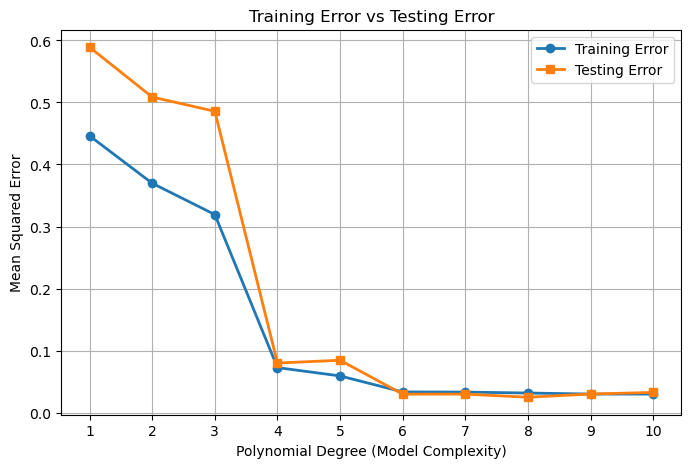

In [25]:
#4. Plot training error vs. test error for models of increasing complexity (e.g., polynomial regression of increasing degree) to visually demonstrate the tradeoff.

# Train models with different polynomial degrees
degrees = range(1, 11)

training_error = []
testing_error = []

for degree in degrees:

    model = make_pipeline(
        PolynomialFeatures(degree),
        LinearRegression()
    )

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    training_error.append(train_mse)
    testing_error.append(test_mse)

# Create ONE figure after the loop
plt.figure(figsize=(8,5))

plt.plot(degrees, training_error,
         marker='o',
         linewidth=2,
         label='Training Error')

plt.plot(degrees, testing_error,
         marker='s',
         linewidth=2,
         label='Testing Error')

plt.title("Training Error vs Testing Error")
plt.xlabel("Polynomial Degree (Model Complexity)")
plt.ylabel("Mean Squared Error")

plt.xticks(degrees)
plt.grid(True)
plt.legend()

plt.show()

 **Graph Explanation**
The graph compares the training error and testing error for models with different polynomial degrees.

 The **training error** decreases as the model becomes more complex because the model fits the training data better.
 
 The **testing error** also decreases at first, showing that the model is learning useful patterns.
 
 After a certain degree, the **testing error starts increasing** while the training error continues to decrease. This indicates **overfitting**, where the model memorizes the training data instead of learning general patterns.

The point where the testing error is the lowest represents the best balance between **bias** and **variance**.

### Part C — Linear Regression: Theory & Implementation

**1. Explain the mathematical form of simple linear regression (y = mx + b) and multiple linear regression.**

**Simple Linear Regression**: predicts a value using one input feature.

Formula: y=mx+b

Where:
y = Predicted value, 
x = Input feature, 
m = Slope (coefficient), 
b = Intercept

**Multiple Linear Regression**: Multiple linear regression uses more than one input feature.

Formula: y=b+m1* x1+m2*x2+⋯+mn*xn

Where:

y = Predicted value
x₁, x₂, ... = Input features
m₁, m₂, ... = Coefficients
b = Intercept

**2. Explain how the model's coefficients are learned (cost function and gradient descent, or the normal equation).**

The model learns the best coefficients by minimizing the prediction error.

A **cost function** measures how much the predictions differ from the actual values.

**Gradient Descent** updates the coefficients step by step to reduce the error.

**Scikit-learn's LinearRegression** uses the Normal Equation, which directly calculates the best coefficients without using gradient descent.


In [34]:
#3. Load a dataset (e.g., a small CSV of your choice or a scikit-learn built-in dataset) and prepare it for modeling.

import pandas as pd
from sklearn.datasets import fetch_california_housing

# Load dataset
housing = fetch_california_housing()

# Features
X = pd.DataFrame(housing.data, columns=housing.feature_names)

# Target
y = housing.target

# Display first five rows
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [29]:
# 4. Split the data into training and test sets, then train a LinearRegression model from scikit-learn.

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Split dataset
X_train, X_test, y_train, y_test = train_test_split( X, y,test_size=0.2,random_state=42)

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

print("Model trained successfully")


Model trained successfully


In [32]:
#5. Evaluate the model using appropriate metrics (e.g., Mean Squared Error, R² score) and interpret the results.

from sklearn.metrics import mean_squared_error, r2_score

# Predictions
y_pred = model.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", round(mse, 3))
print("\nR² Score:", round(r2, 3))

#Mean Squared Error (MSE): Measures the average prediction error. A lower value indicates better performance.

#R² Score: Shows how well the model explains the data. A value closer to 1 indicates a better model.

Mean Squared Error: 0.556

R² Score: 0.576


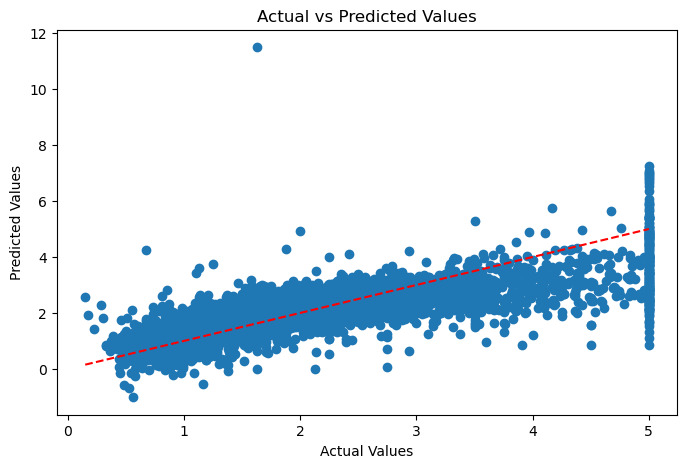

In [33]:
#6. Plot the regression line (or predicted vs. actual values) against the data.

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")

plt.show()

### Part D — Practical Coding Session

1. Load a raw CSV dataset, handle missing values, and encode any categorical columns before modeling.

2. Write a function that takes a dataset and a split ratio, returns train/test sets, and prints the resulting shapes.

3. Train the same Linear Regression model on three different train/test split ratios (e.g., 60/40, 80/20, 90/10) and compare the evaluation metrics in a small table.

4. Use scikit-learn's cross_val_score to perform k-fold cross-validation on your model and report the average score.

5. Plot a learning curve (training score vs. test score as training set size increases) and explain what it shows about overfitting or underfitting.

6.  Refactor your notebook code into reusable functions (e.g., load_data(), split_data(), train_model(), evaluate_model()).


In [36]:
#1. Load a raw CSV dataset, handle missing values, and encode any categorical columns before modeling.

import pandas as pd
import numpy as np

from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import LabelEncoder

# Load dataset
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Add target column
df["Price"] = housing.target

# Create a sample categorical column
df["Region"] = np.where(df["Latitude"] > 36, "North", "South")

# Create some missing values for demonstration
df.loc[0:10, "MedInc"] = np.nan

print("Missing Values Before:")
print(df.isnull().sum())

# Fill missing values with the column mean
mean_value = df["MedInc"].mean()
df["MedInc"] = df["MedInc"].fillna(mean_value)

# Encode categorical column
encoder = LabelEncoder()
df["Region"] = encoder.fit_transform(df["Region"])

print("\nMissing Values After:")
print(df.isnull().sum())

df.head()


Missing Values Before:
MedInc        11
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
Price          0
Region         0
dtype: int64

Missing Values After:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
Region        0
dtype: int64


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price,Region
0,3.870158,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,0
1,3.870158,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,0
2,3.870158,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,0
3,3.870158,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,0
4,3.870158,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,0


In [37]:
#2. Write a function that takes a dataset and a split ratio, returns train/test sets, and prints the resulting shapes.

from sklearn.model_selection import train_test_split

X = df.drop("Price", axis=1)
y = df["Price"]

def split_data(X, y, ratio):

    X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=ratio, random_state=42)

    print(f"\nTrain/Test Split = {int((1-ratio)*100)}/{int(ratio*100)}")
    print("Training Features :", X_train.shape)
    print("Testing Features  :", X_test.shape)

    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = split_data(X, y, 0.2)


Train/Test Split = 80/20
Training Features : (16512, 9)
Testing Features  : (4128, 9)


In [38]:
#3. Train the same Linear Regression model on three different train/test split ratios (e.g., 60/40, 80/20, 90/10) and compare the evaluation metrics in a small table.

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

results = []

ratios = [0.4, 0.2, 0.1]

for ratio in ratios:

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=ratio,
        random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append([
        f"{int((1-ratio)*100)}/{int(ratio*100)}",
        round(mse,3),
        round(r2,3)
    ])

results_df = pd.DataFrame(
    results,
    columns=["Split Ratio","MSE","R² Score"]
)

results_df

,Split Ratio,MSE,R² Score
0,60/40,0.543,0.595
1,80/20,0.556,0.576
2,90/10,0.557,0.582


In [39]:
#4. Use scikit-learn's cross_val_score to perform k-fold cross-validation on your model and report the average score.

from sklearn.model_selection import cross_val_score

model = LinearRegression()

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Cross Validation Scores:")
print(scores)

print("\nAverage R² Score:", round(scores.mean(),3))

Cross Validation Scores:
[0.54556557 0.4724572  0.55428151 0.5415078  0.65327316]

Average R² Score: 0.553


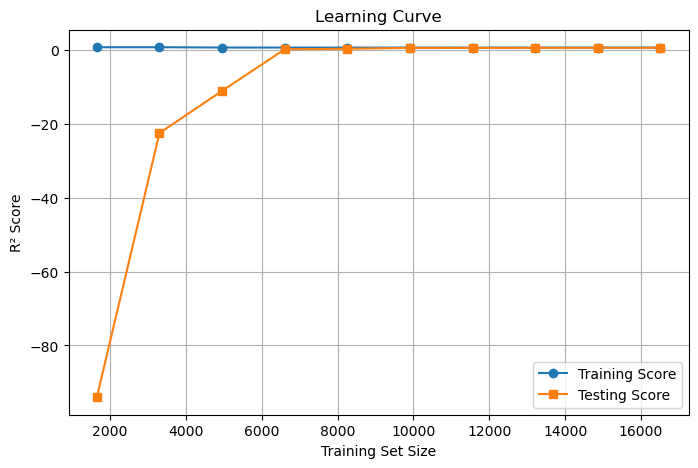

In [40]:
#5. Plot a learning curve (training score vs. test score as training set size increases) and explain what it shows about overfitting or underfitting.

import matplotlib.pyplot as plt

from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    LinearRegression(),
    X,
    y,
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.1,1.0,10)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))

plt.plot(train_sizes, train_mean,
         marker='o',
         label="Training Score")

plt.plot(train_sizes, test_mean,
         marker='s',
         label="Testing Score")

plt.xlabel("Training Set Size")
plt.ylabel("R² Score")
plt.title("Learning Curve")

plt.grid(True)
plt.legend()

plt.show()

**Learning Curve Explanation**

The learning curve shows how the model's performance changes as the training data increases.

The training score is usually high at first and may decrease slightly as more data is added.

The testing score improves as the model learns from more training data.

If the two lines become close together, the model is generalizing well.

If there is a large gap between the lines, the model may be overfitting.

In [41]:
#6. Refactor your notebook code into reusable functions (e.g., load_data(), split_data(), train_model(), evaluate_model()).

# Import Libraries

import pandas as pd
import numpy as np

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Function 1: Load and Prepare Data
def load_data():

    # Load California Housing dataset
    housing = fetch_california_housing()

    # Create DataFrame
    df = pd.DataFrame(housing.data, columns=housing.feature_names)

    # Add target column
    df["Price"] = housing.target

    # Create a sample categorical column
    df["Region"] = np.where(df["Latitude"] > 36, "North", "South")

    # Add some missing values (for demonstration)
    df.loc[0:10, "MedInc"] = np.nan

    # Fill missing values
    df["MedInc"] = df["MedInc"].fillna(df["MedInc"].mean())

    # Encode categorical column
    df["Region"] = df["Region"].map({
        "North": 1,
        "South": 0
    })

    print("Dataset loaded and prepared successfully.\n")

    return df


# Function 2: Split Data

def split_data(df, test_size):

    X = df.drop("Price", axis=1)
    y = df["Price"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=42
    )

    print(f"Train/Test Split ({int((1-test_size)*100)}/{int(test_size*100)})")
    print("-----------------------------------")
    print("Training Features :", X_train.shape)
    print("Testing Features  :", X_test.shape)
    print("Training Labels   :", y_train.shape)
    print("Testing Labels    :", y_test.shape)

    return X_train, X_test, y_train, y_test


# Function 3: Train Model

def train_model(X_train, y_train):

    model = LinearRegression()

    model.fit(X_train, y_train)

    print("\nModel trained successfully.")

    return model

# Function 4: Evaluate Model


def evaluate_model(model, X_test, y_test):

    predictions = model.predict(X_test)

    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    print("\nModel Evaluation/:")
   
    print("Mean Squared Error :", round(mse, 3))
    print("R² Score           :", round(r2, 3))



# Load dataset
df = load_data()

# Split dataset
X_train, X_test, y_train, y_test = split_data(df, 0.20)

# Train model
model = train_model(X_train, y_train)

# Evaluate model
evaluate_model(model, X_test, y_test)

Dataset loaded and prepared successfully.

Train/Test Split (80/20)
-----------------------------------
Training Features : (16512, 9)
Testing Features  : (4128, 9)
Training Labels   : (16512,)
Testing Labels    : (4128,)

Model trained successfully.

Model Evaluation/:
Mean Squared Error : 0.556
R² Score           : 0.576


### Bonus Task 
Extend your Linear Regression model with polynomial features (degree 2 or 3) and compare its performance against the plain linear model. Explain, using your results, whether the polynomial version overfits, underfits, or generalizes better.


Model Performance Comparison

                   Model  Mean Squared Error  R² Score
0      Linear Regression               0.556     0.576
1  Polynomial Regression               0.464     0.646


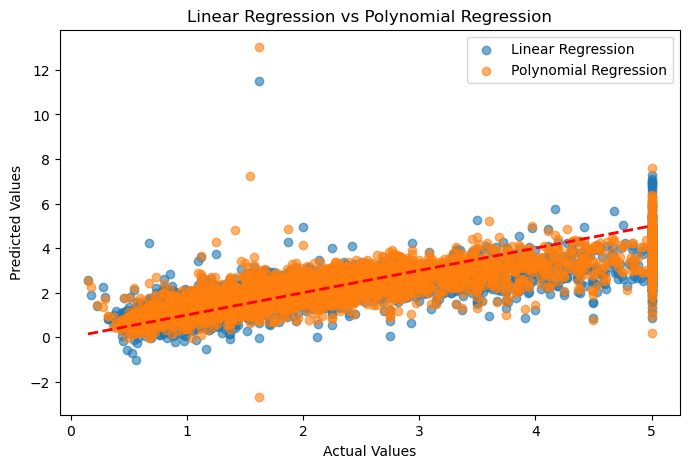

In [42]:
#Extend your Linear Regression model with polynomial features (degree 2 or 3) and compare its performance against the plain linear model. Explain, using your results, whether the polynomial version overfits, underfits, or generalizes better.

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
housing = fetch_california_housing()

X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Linear Regression

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

linear_mse = mean_squared_error(y_test, linear_pred)
linear_r2 = r2_score(y_test, linear_pred)

# Polynomial Regression (Degree 2)

poly_model = make_pipeline(
    PolynomialFeatures(degree=2),
    LinearRegression()
)

poly_model.fit(X_train, y_train)

poly_pred = poly_model.predict(X_test)

poly_mse = mean_squared_error(y_test, poly_pred)
poly_r2 = r2_score(y_test, poly_pred)

# Display Results

results = pd.DataFrame({
    "Model": ["Linear Regression", "Polynomial Regression"],
    "Mean Squared Error": [round(linear_mse, 3), round(poly_mse, 3)],
    "R² Score": [round(linear_r2, 3), round(poly_r2, 3)]
})

print("Model Performance Comparison\n")
print(results)

# Plot Actual vs Predicted
plt.figure(figsize=(8,5))

plt.scatter(y_test, linear_pred, alpha=0.6, label="Linear Regression")
plt.scatter(y_test, poly_pred, alpha=0.6, label="Polynomial Regression")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression vs Polynomial Regression")
plt.legend()

plt.show()